In [37]:
import pandas as pd 
import os 

In [39]:
os.listdir()

['.ipynb_checkpoints',
 '.virtual_documents',
 'anaconda_projects',
 'Food Delivery Data Processing.ipynb',
 'raw.csv']

In [41]:
df = pd.read_csv("raw.csv")

In [43]:
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [45]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [47]:
df = df.drop_duplicates()

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [53]:
df['Weather'] = df['Weather'].fillna('Unknown')
df['Traffic_Level'] = df['Traffic_Level'].fillna('Unknown')
df['Time_of_Day'] = df['Time_of_Day'].fillna('Unknown')

In [55]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [57]:
df['Speed_km_per_min'] = df['Distance_km'] / df['Delivery_Time_min']

In [59]:
df['Delivery_Category'] = df['Delivery_Time_min'].apply(
    lambda x: 'Fast' if x < 40 else ('Medium' if x < 70 else 'Slow')
)

Using EDA

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

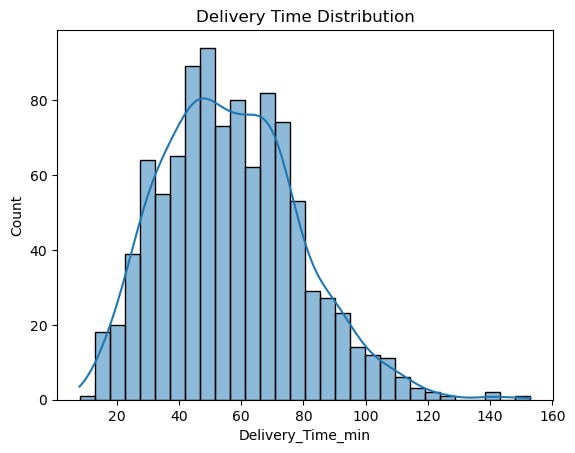

In [65]:
sns.histplot(df['Delivery_Time_min'], bins=30, kde=True)
plt.title("Delivery Time Distribution")
plt.show()

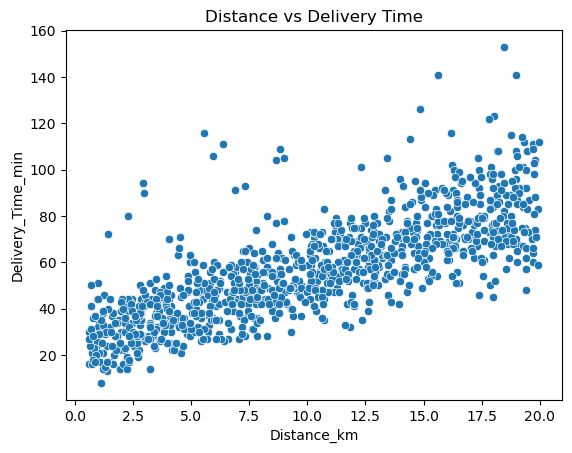

In [67]:
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df)
plt.title("Distance vs Delivery Time")
plt.show()

Delivery time increases with distance.

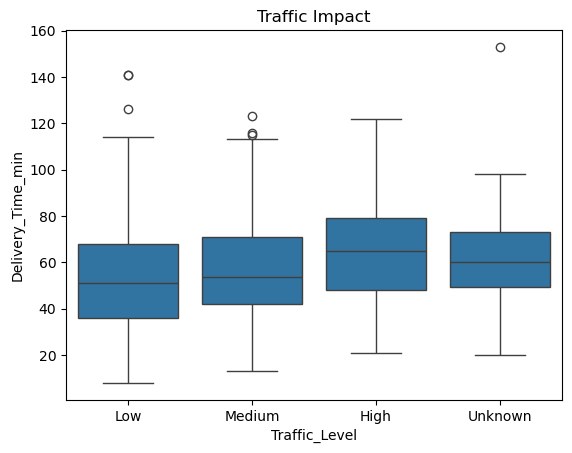

In [69]:
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df)
plt.title("Traffic Impact")
plt.show()

High traffic leads to significant delays.

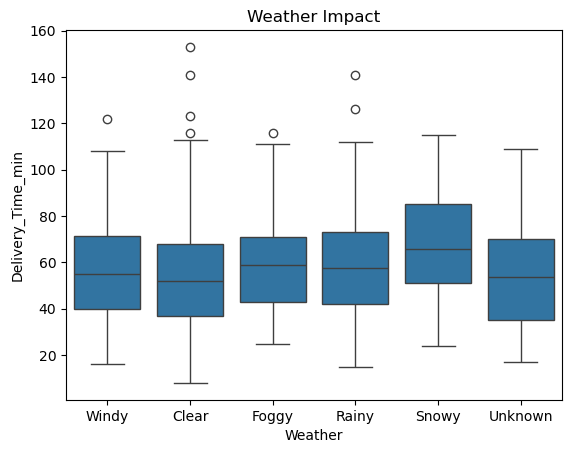

In [71]:
sns.boxplot(x='Weather', y='Delivery_Time_min', data=df)
plt.title("Weather Impact")
plt.show()

Rainy and snowy weather increase delivery time.

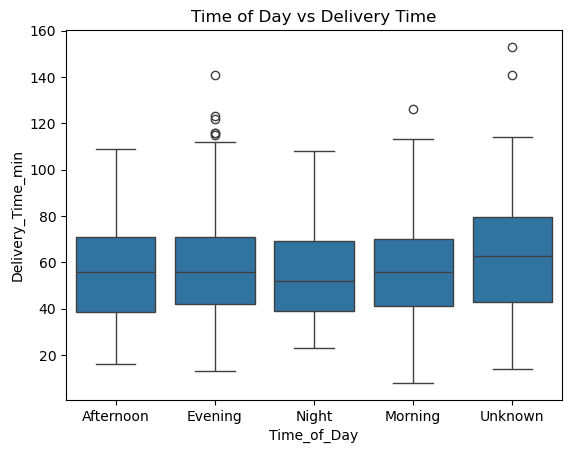

In [73]:
sns.boxplot(x='Time_of_Day', y='Delivery_Time_min', data=df)
plt.title("Time of Day vs Delivery Time")
plt.show()

Evening time shows peak delivery delays.

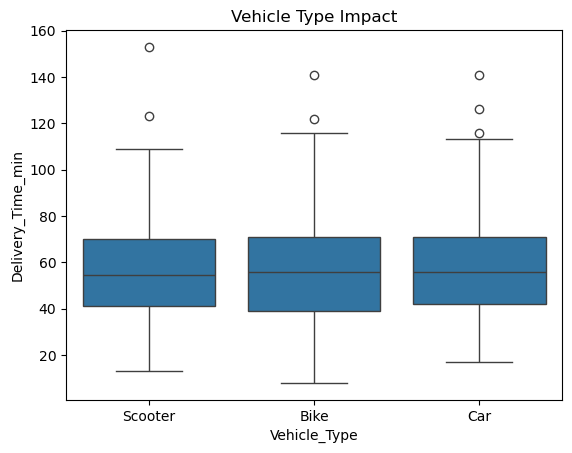

In [75]:
sns.boxplot(x='Vehicle_Type', y='Delivery_Time_min', data=df)
plt.title("Vehicle Type Impact")
plt.show()

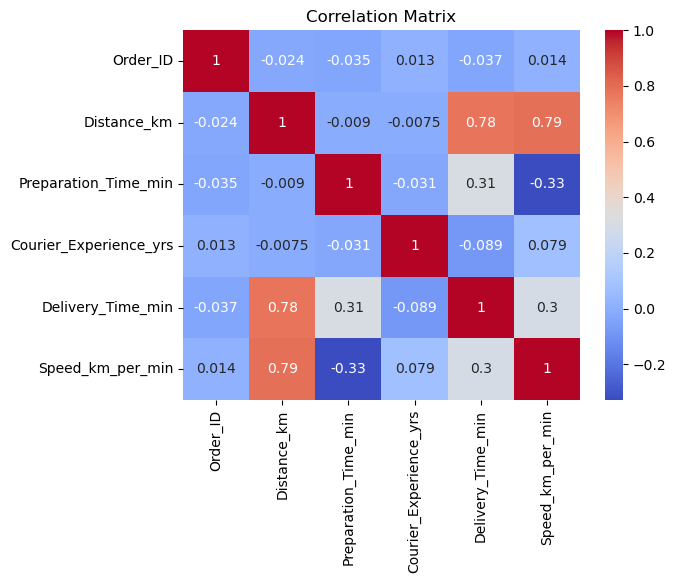

In [77]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Train ML Model

In [79]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [81]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(['Delivery_Time_min', 'Order_ID'], axis=1)
y = df_encoded['Delivery_Time_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [85]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 2.3322


Clean data 

In [87]:
df.to_csv("cleaned_food_delivery.csv", index=False)